In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# CDS Monthly

In [44]:
t2m = xr.open_mfdataset("data/era5_monthly/era5_monthly_precipitation_*.nc", combine="by_coords", parallel=True)
t2m.close()
tp  = xr.open_mfdataset("data/era5_monthly/era5_monthly_temperature_*.nc",  combine="by_coords", parallel=True)
tp.close()
vpd = xr.open_mfdataset("data/era5_derived_monthly.nc", combine="by_coords", parallel=True)
vpd.close()


t2m = t2m.assign_coords(valid_time=t2m.valid_time.dt.floor("D"))
tp = tp.assign_coords(valid_time=tp.valid_time.dt.floor("D"))
vpd = vpd.assign_coords(valid_time=vpd.valid_time.dt.floor("D"))

ds_monthly = xr.merge([t2m, tp, vpd], compat="override")
ds_monthly = ds_monthly.drop_vars("number")
    
print(ds_monthly)

vpd
<xarray.Dataset> Size: 4MB
Dimensions:                  (valid_time: 312, latitude: 32, longitude: 54)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 2kB 2000-01-01 ... 2...
  * latitude                 (latitude) float64 256B 44.0 43.75 ... 36.5 36.25
  * longitude                (longitude) float64 432B -10.0 -9.75 ... 3.0 3.25
    number                   int64 8B ...
Data variables:
    vpd_monthly_mean_daymax  (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(312, 32, 54), meta=np.ndarray>
    wind_speed_monthly       (valid_time, latitude, longitude) float32 2MB dask.array<chunksize=(312, 32, 54), meta=np.ndarray>
------------
ds_monthly
<xarray.Dataset> Size: 9MB
Dimensions:                  (valid_time: 312, latitude: 32, longitude: 54)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 2kB 2000-01-01 ... 2...
    expver                   (valid_time) <U4 5kB dask.array<chunksize=(12,), meta=np.ndarray>
  * latitud

In [45]:
# Apply land-sea mask:

lsm = xr.open_dataset("data/era5_static/era5_lsm.nc")["lsm"].squeeze()
lsm = lsm.reindex_like(ds_monthly, method="nearest")
ds_monthly_land = ds_monthly.where(lsm > 0.5)

In [46]:
print(f'Number of valid times: {ds_monthly.sizes["valid_time"]}') # Should be 312 = 26 years x 12 months
print(f'Number of nulls in t2m: {ds_monthly["t2m"].isnull().sum().compute().item()}') # Should be zero
print(f'Number of nulls in tp: {ds_monthly["tp"].isnull().sum().compute().item()}') # Should be zero


Number of valid times: 312
Number of nulls in t2m: 0
Number of nulls in tp: 0


In [61]:
quantiles = [0, 0.25, 0.5, 0.75, 1.0]

q = (
    ds_monthly_land[["t2m", "tp", "vpd_monthly_mean_daymax", "wind_speed_monthly"]]
    .groupby("valid_time.month")
    .quantile(quantiles, dim=...)   # ... means "all remaining dims"
    .compute()
)

df = q.to_dataframe().unstack("quantile").round(2)
df.index = pd.to_datetime(df.index, format="%m").strftime("%b")
df.index.name = "month"

ds_monthly_display = ds_monthly_land.assign(
    t2m=ds_monthly_land["t2m"] - 273.15,
    tp=ds_monthly_land["tp"] * ds_monthly.valid_time.dt.days_in_month * 1000,  # mm/month

)
ds_monthly_display.t2m.attrs["long_name"] = "Temperature at 2 meters"
ds_monthly_display.t2m.attrs["units"] = "ºC"
ds_monthly_display.tp.attrs["long_name"] = "Total precipitation"
ds_monthly_display.tp.attrs["units"] = "mm/month"
ds_monthly_display.vpd_monthly_mean_daymax.attrs["long_name"] = "VPD Daily Maximum"
ds_monthly_display.vpd_monthly_mean_daymax.attrs["units"] = "hPA"
ds_monthly_display.wind_speed_monthly.attrs["long_name"] = "Wind speed"
ds_monthly_display.wind_speed_monthly.attrs["units"] = "m/s"

ds_monthly_display = ds_monthly_display.drop_vars("number")

q = (
    ds_monthly_display[["t2m", "tp", "vpd_monthly_mean_daymax", "wind_speed_monthly"]]
    .groupby("valid_time.month")
    .quantile(quantiles, dim=...)
    .compute()
)

df = q.to_dataframe().unstack("quantile").round(2)
df.index = pd.to_datetime(df.index, format="%m").strftime("%b")

print("Temperature at 2 meters in ºC")
print(df["t2m"])
print("-------------------------------------------------")
print("Total precipitation in mm/month")
print(df["tp"])
print("-------------------------------------------------")
print("Vapor Pressure Deficit (VPD) daily maximum in hPA")
print(df["vpd_monthly_mean_daymax"])
print("-------------------------------------------------")
print("Wind speed in m/s")
print(df["wind_speed_monthly"])


Temperature at 2 meters in ºC
quantile   0.00   0.25   0.50   0.75   1.00
month                                      
Jan       -4.89   4.51   6.36   8.49  14.82
Feb       -6.97   5.61   7.81   9.87  15.64
Mar       -1.53   8.31  10.17  12.04  18.11
Apr        1.35  10.70  12.62  14.50  20.90
May        3.22  14.04  16.31  18.38  24.16
Jun        9.91  18.37  20.91  23.04  29.22
Jul       12.53  20.59  23.52  25.90  32.00
Aug       11.99  20.65  23.36  25.83  31.11
Sep        8.76  17.40  19.58  21.78  26.59
Oct        3.59  13.49  15.51  17.54  23.69
Nov       -1.92   7.96  10.00  12.06  19.24
Dec       -6.03   5.24   7.15   9.29  16.52
-------------------------------------------------
Total precipitation in mm/month
quantile  0.00   0.25   0.50    0.75    1.00
month                                       
Jan       0.00  27.67  50.73   91.53  676.66
Feb       0.06  22.02  47.24   76.77  479.26
Mar       0.95  32.58  62.75  105.66  925.53
Apr       0.49  43.20  70.22  100.54  506.57
Ma

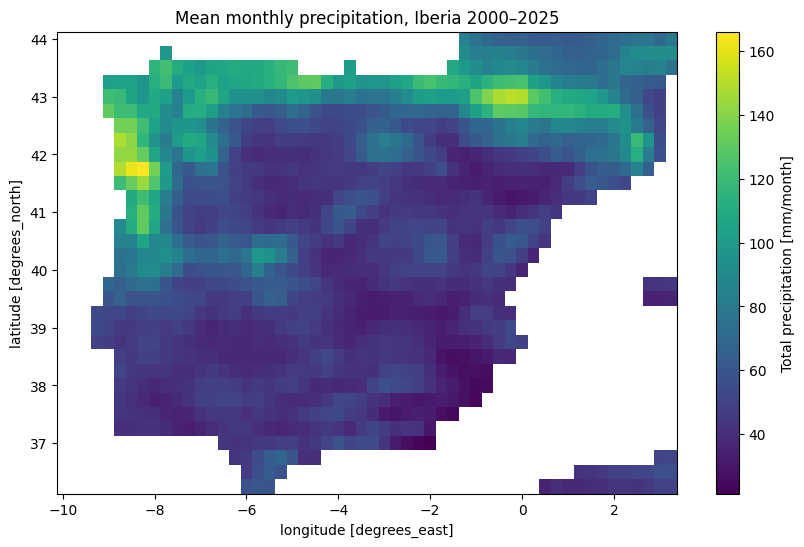

In [30]:
ds_monthly_display.tp.mean(dim="valid_time").plot(figsize=(10, 6))
plt.title("Mean monthly precipitation, Iberia 2000–2025")
plt.show()


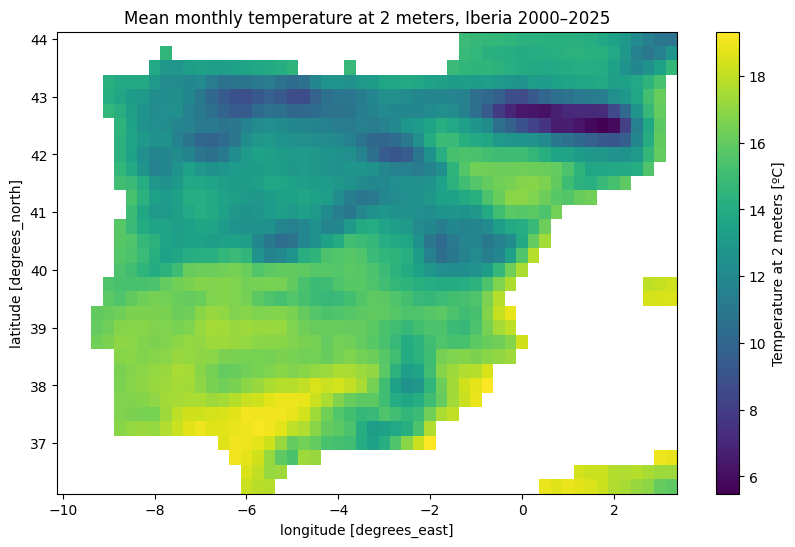

In [31]:
ds_monthly_display.t2m.mean(dim="valid_time").plot(figsize=(10, 6))
plt.title("Mean monthly temperature at 2 meters, Iberia 2000–2025")
plt.show()

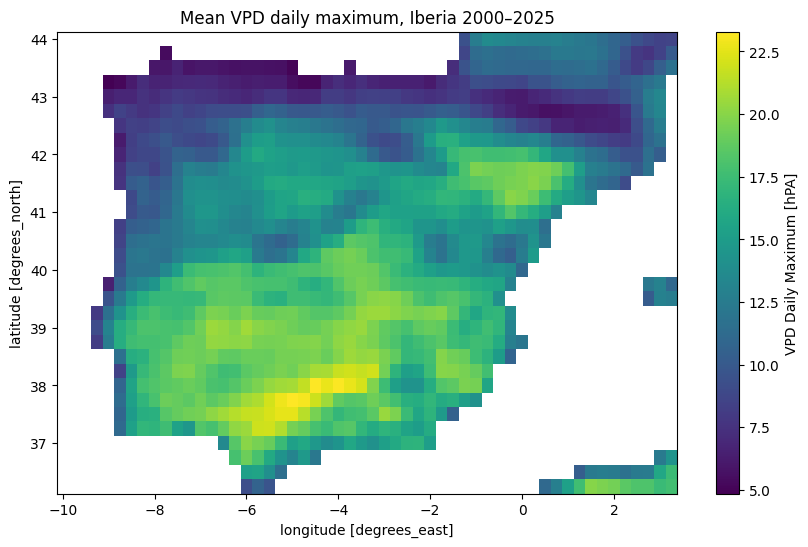

In [59]:
ds_monthly_display.vpd_monthly_mean_daymax.mean(dim="valid_time").plot(figsize=(10, 6))
plt.title("Mean VPD daily maximum, Iberia 2000–2025")
plt.show()

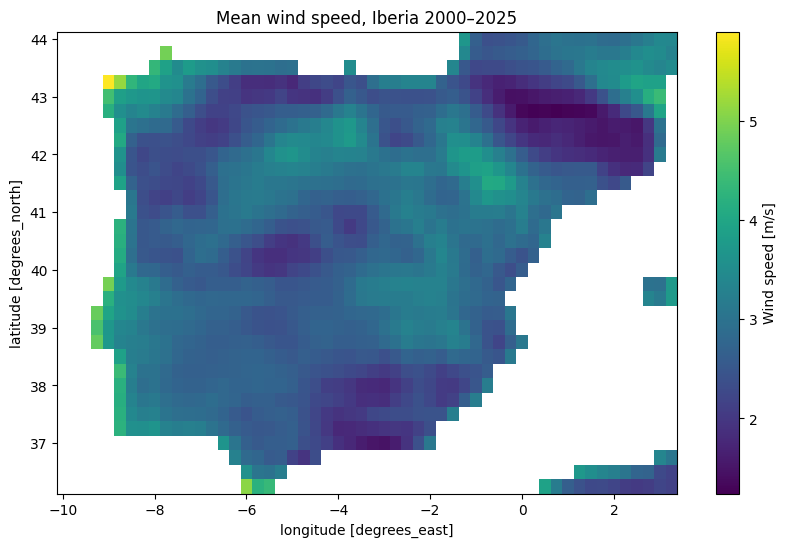

In [62]:
ds_monthly_display.wind_speed_monthly.mean(dim="valid_time").plot(figsize=(10, 6))
plt.title("Mean wind speed, Iberia 2000–2025")
plt.show()